In [1]:
from pathlib import Path
import os, sys

PROJECT_ROOT = Path.cwd().resolve().parents[1]
if Path.cwd().resolve() != PROJECT_ROOT:
    os.chdir(PROJECT_ROOT)

root_str = str(PROJECT_ROOT)
if root_str in sys.path:
    sys.path.remove(root_str)
sys.path.insert(0, root_str)

#print("PROJECT_ROOT =", PROJECT_ROOT)
#print("cwd =", Path.cwd())

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="Observation names are not unique. To make them unique, call `.obs_names_make_unique`."
)
warnings.filterwarnings(
    "ignore",
    message= "RuntimeWarning: invalid value encountered in divide"
)


In [4]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import torch
import yaml
import scvi
import pickle

In [5]:
control_key = "is_control"
condition_keys = "perturbation"
condition_combined_keys = "condition_combined"
condition_rep_keys = "perturbation_embeddings"
mass_deduct_keys = "plate_well"

data_origin = "Sciplex3_llm_test1_42_cellflow_True_X_pca_100_None" #{dataset_name}_{random_seed}_{test_ratio}_{zero_shot}_{sample_rep_scaled}_{n_comps}
sample_rep = "X_pca"
scvi_model_load_path = f"./data/processed/model/X_scVI_ncomps512_hidden1024_layers2_PBMC_donor11_hvg2000_e5test3_42_0.2_True"
state_model_load_path = f"./data/processed/model/X_state_ArcVirtualCell.pt"
experiment = "exp_20260409_140223_Sciplex3_llm_test1_42_cellflow_True_X_pca_100_None_delta6_regm3"

experiment_load_path = os.path.join("experiments",experiment)
config_load_path = os.path.join(experiment_load_path, "config.yaml")
model_load_path = os.path.join(experiment_load_path, "checkpoints", "test_11_epoch_10000.pt") 
results_save_path = os.path.join("results",experiment)
os.makedirs(results_save_path, exist_ok=True)

In [6]:
# load data
preprocess_save_path = f"./data/processed/{data_origin}"
adata_control = sc.read_h5ad(f"{preprocess_save_path}_control.h5ad")
adata_train = sc.read_h5ad(f"{preprocess_save_path}_train.h5ad")
if os.path.exists(f"{preprocess_save_path}_test.h5ad"):
    adata_test = sc.read_h5ad(f"{preprocess_save_path}_test.h5ad")
else:
    adata_test = None
print(adata_control)
print(adata_train)
print(adata_test)

AnnData object with n_obs × n_vars = 17578 × 2000
    obs: 'ncounts', 'well', 'plate', 'cell_line', 'replicate', 'time', 'dose_value', 'pathway_level_1', 'pathway_level_2', 'perturbation', 'target', 'pathway', 'dose_unit', 'celltype', 'disease', 'cancer', 'tissue_type', 'organism', 'perturbation_type', 'is_control', 'plate_well', 'cell_line_idx', 'dose_value_scaled', 'time_scaled', 'condition_combined'
    var: 'ensembl_id', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cov_config', 'global_rulebook', 'hvg', 'log1p', 'normalized_m', 'pca', 'perturbation_embeddings'
    obsm: 'X_pca'
    varm: 'PCs', 'X_mean'
    layers: 'counts'
AnnData object with n_obs × n_vars = 718049 × 2000
    obs: 'ncounts', 'well', 'plate', 'cell_line', 'replicate', 'time', 'dose_value', 'pathway_level_1', 'pathway_level_2', 'perturbation', 'target', 'pathway', 'dose_unit', 'celltype', 'disease', 'cancer', 'tissue_type', 'organism', 'perturbation_type', 'is_control', 'plate_well', 'cel

In [7]:
# load model
from src.training import FNet
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
with open(config_load_path, 'r') as f:
    config = yaml.safe_load(f)
    print(f"load saved_config from {config_load_path}")


model = FNet(
    in_out_dim=config["in_out_dim"], 
    rulebook = adata_control.uns["global_rulebook"],
    hidden_dim_v=config["hidden_dim_v"], 
    n_hiddens_v=config["n_hiddens_v"], 
    hidden_dim_g=config["hidden_dim_g"], 
    n_hiddens_g=config["n_hiddens_g"], 
    condition_dim=config["condition_dim"], 
    con_embedding_dim=config["con_embedding_dim"], 
    hidden_dim_con=config["hidden_dim_con"], 
    time_dim=config["time_dim"], 
    time_embedding_dim=config["time_embedding_dim"], 
    hidden_dim_time=config["hidden_dim_time"], 
    bottle_dim=config["bottle_dim"], 
    cov_emb_dim=config.get("cov_emb_dim", 64), 
    dropout=config["dropout"], 
    activation=config["activation"]
)

checkpoint = torch.load(model_load_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

load saved_config from experiments/exp_20260409_140223_Sciplex3_llm_test1_42_cellflow_True_X_pca_100_None_delta6_regm3/config.yaml


FNet(
  (t_encoder): TimeEncoder()
  (activation): SiLU()
  (condition_encoder): Sequential(
    (0): LayerNorm((3072,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=3072, out_features=512, bias=True)
    (2): SiLU()
    (3): Linear(in_features=512, out_features=512, bias=True)
    (4): SiLU()
    (5): Linear(in_features=512, out_features=256, bias=True)
  )
  (time_mlp): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): SiLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
  )
  (cov_encoders): ModuleDict(
    (cell_line): Embedding(3, 64)
    (dose_value): Sequential(
      (0): Linear(in_features=1, out_features=32, bias=True)
      (1): SiLU()
      (2): Linear(in_features=32, out_features=64, bias=True)
    )
    (time): Sequential(
      (0): Linear(in_features=1, out_features=32, bias=True)
      (1): SiLU()
      (2): Linear(in_features=32, out_features=64, bias=True)
    )
  )
  (v_net): Velocity_GrowthNet(
   

训练步数: 9900
最后一步 Loss: 0.306601
最后一步 vLoss: 0.295235
最后一步 gLoss: 0.011366
最后一步 test_Loss: 0.559369
最后一步 test_vLoss: 0.239798
最后一步 test_gLoss: 0.319572


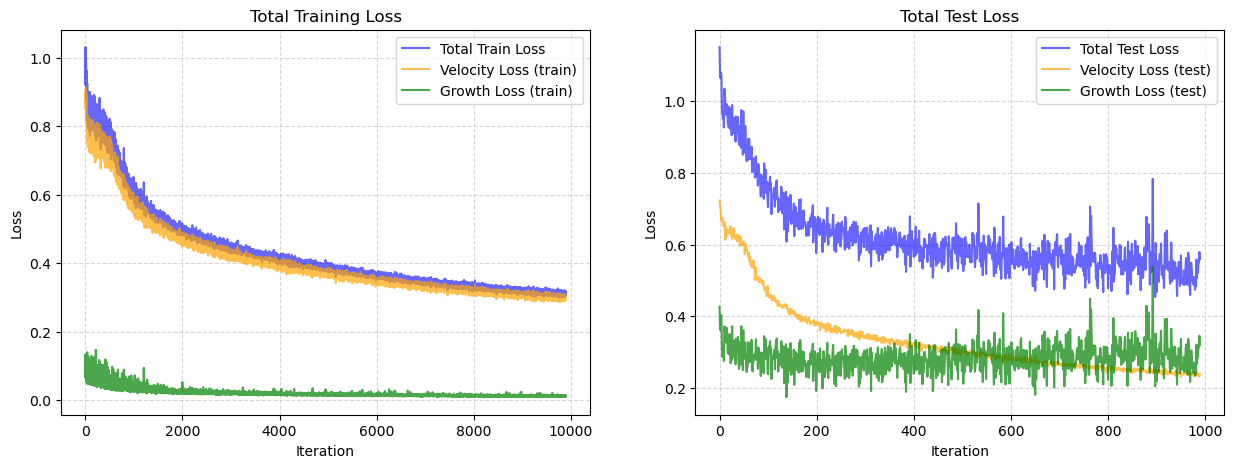

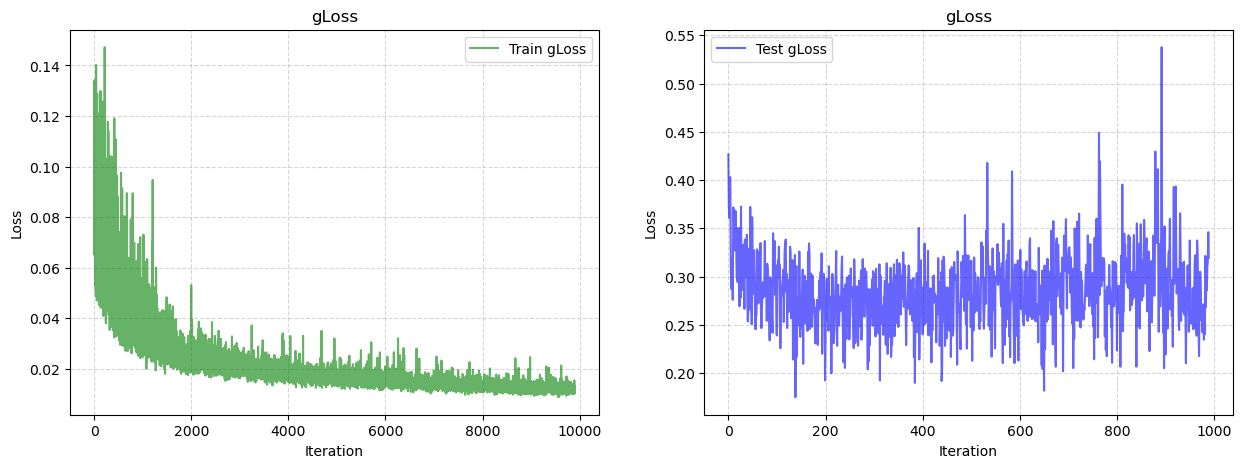

In [8]:
from src.evaluate import draw_loss
draw_loss(model_load_path,eval_interval = 10,cut = 100,save_path = results_save_path) # cut代表去掉前多少个epoch 避免前期loss过大影响观察

## inference & evalutaion

In [8]:
from src.evaluate.downstream import *
from src.evaluate.util import run_inference_and_reconstruct,evaluate_generated_results
from src.evaluate.evals_new import build_baseline_results

In [9]:
rulebook = adata_test.uns.get('global_rulebook')
if rulebook is None:
    raise ValueError("未找到 global_rulebook，请先确认数据经过了最新版 prepare_covariates 的处理！")

schema = rulebook["condition_tuple_schema"] 

# 我们直接从 adata_test 中，根据 schema 提取所有出现过的独立条件组合
# 然后直接转化为字典列表，这就是完美的 wishlist！
unique_conditions_df = adata_test.obs[schema].drop_duplicates()
wishlist = unique_conditions_df.to_dict(orient='records')

print(f"成功从测试集中提取了 {len(wishlist)} 个评估愿望 (Wishlist)！")
print(f"示例: {wishlist[0]}") 

# base_condition_key 通常是 schema 的第一个元素（如 'perturbation'）
base_condition_key = schema[0] 

# rulebook = adata_train.uns.get('global_rulebook')
# schema = rulebook["condition_tuple_schema"] 
# unique_conditions_df = adata_train.obs[schema].drop_duplicates()
# wishlist = unique_conditions_df.to_dict(orient='records')
# print(f"成功从测试集中提取了 {len(wishlist)} 个评估愿望 (Wishlist)！")
# print(f"示例: {wishlist[0]}") 
# base_condition_key = schema[0] 

成功从测试集中提取了 124 个评估愿望 (Wishlist)！
示例: {'perturbation': 'TAK-901', 'cell_line': 'MCF7', 'dose_value': 10000.0, 'time': 24.0}


In [10]:
wishlist = [ k for k in wishlist if k['dose_value']==10000  ]

In [11]:
len(wishlist)

124

In [12]:
# 第一步：只管推断和生成
results_embedding, results_genes, sampled_indices = run_inference_and_reconstruct(
    model=model,
    adata_control=adata_control,
    adata_test=adata_test,
    wishlist=wishlist,
    condition_keys=condition_keys,
    condition_rep_keys=condition_rep_keys,
    sample_rep=sample_rep,
    device="cuda",
    n_particles = 100000,
    random_seed = 42,
    n_steps = 50,
    source_celltype_key="cell_line",
)

inference_results = {"results_embedding":results_embedding,"results_genes":results_genes,"sampled_indices": sampled_indices}
with open(f"{results_save_path}/inference_results.pkl", "wb") as f:
    pickle.dump(inference_results, f)
    print(f"save inference_results to {results_save_path}/inference_results.pkl")

Starting inference for 124 conditions...
准备为 124 个条件进行推理...


100%|██████████| 124/124 [03:22<00:00,  1.63s/it]


Starting gene expression reconstruction...


  0%|          | 0/124 [00:00<?, ?it/s]/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/anndata/_core/anndata.py:401: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
  1%|          | 1/124 [00:01<02:41,  1.32s/it]/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/anndata/_core/anndata.py:401: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
  2%|▏         | 2/124 [00:01<01:17,  1.57it/s]/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/anndata/_core/anndata.py:401: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/anndata/_core/anndata.py:401: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  wa

Inference and reconstruction completed.
save inference_results to results/exp_20260409_140223_Sciplex3_llm_test1_42_cellflow_True_X_pca_100_None_delta6_regm3/inference_results.pkl


In [14]:
if False:
    with open(f"{results_save_path}/inference_results.pkl", "rb") as f:
        inference_results = pickle.load(f)
        print(f"load inference_results")
    results_embedding = inference_results["results_embedding"]
    results_genes = inference_results["results_genes"]
    sampled_indices = inference_results["sampled_indices"]

In [13]:
final_df, eval_artifacts = evaluate_generated_results(
    results_embedding=results_embedding,
    results_genes=results_genes,
    adata_control=adata_control,
    adata_test=adata_test,
    condition_combined_keys=condition_combined_keys,
    control_key=control_key,
    sample_rep=sample_rep,
    results_save_path=results_save_path,
    mass_deduct_keys=mass_deduct_keys,
    random_seed = 42,
    Edistance_sample_num = 10000,
    dist_max_cells= 10000,
    dist_top_n_degs = 50,
    deg_padj_cutoff = 0.01,
    deg_fc_cutoff = 1.0,
    deg_top_n_for_eval = 50,
    save_each = True,
    save_final = True,
    final_filename= "final_metrics_test.csv",
    use_groupwise_control = True,
    cell_type_key = "cell_line",
    celltype_transition_rules = None,
    celltype_transition_unknown_policy="same_only",
    detailed_perturbation = False,
    detailed_celltype = False,
)


Evaluating Latent metrics (MSE, R2, PCC Delta, Wasserstein/Sinkhorn, etc.)...
Start evaluating 124 perturbations (Latent Space)
Evaluating Population Average metrics...
Start evaluating 124 perturbations (Pseudo-bulk)


/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:347: RuntimeWarning: invalid value encountered in divide
  scores = (
/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:347: RuntimeWarning: invalid value encountered in divide
  scores = (
/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:347: RuntimeWarning: invalid value encountered in divide
  scores = (
/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:347: RuntimeWarning: invalid value encountered in divide
  scores = (
/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:347: RuntimeWarning: invalid value encountered in divide
  scores = (
/lustre/home/2300012

Evaluating Population Distribution metrics...
Start evaluating 124 perturbations (DEG overlap, mass-aware pred)


/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:347: RuntimeWarning: invalid value encountered in divide
  scores = (
/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:347: RuntimeWarning: invalid value encountered in divide
  scores = (
/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:347: RuntimeWarning: invalid value encountered in divide
  scores = (
/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:347: RuntimeWarning: invalid value encountered in divide
  scores = (
/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:347: RuntimeWarning: invalid value encountered in divide
  scores = (
/lustre/home/2300012


--- Starting Stratified Evaluation ---
Training KNN (k=15) for label transfer using 'X_pca'...
Label transfer completed.
Start evaluating Cell-type specific metrics across 124 perturbations...


/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:347: RuntimeWarning: invalid value encountered in divide
  scores = (
/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:347: RuntimeWarning: invalid value encountered in divide
  scores = (
/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:347: RuntimeWarning: invalid value encountered in divide
  scores = (
/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:347: RuntimeWarning: invalid value encountered in divide
  scores = (
/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:347: RuntimeWarning: invalid value encountered in divide
  scores = (
/lustre/home/2300012

All evaluations completed. Results saved to results/exp_20260409_140223_Sciplex3_llm_test1_42_cellflow_True_X_pca_100_None_delta6_regm3/final_metrics_test.csv


In [14]:
print(final_df)

  perturbation  latent_mse  latent_r2  latent_pcc_delta  \
0         mean    0.167206   0.682464          0.407112   

   latent_energy_distance  latent_wasserstein  mse_gene  mse_identity  \
0                33.46758          103.559052  0.011302      0.016504   

   mae_gene   r2_gene  ...  celltype_prop_rmse_mass  celltype_prop_js_mass  \
0  0.025385  0.735856  ...                 0.022463                 0.0123   

   celltype_offtarget_mass_ratio  celltype_prop_max_abs_err_mass  \
0                        0.02996                         0.02996   

   celltype_change_mass_ratio  celltype_allowed_change_mass_ratio  \
0                     0.02996                                 0.0   

   celltype_wrong_change_mass_ratio  celltype_unknown_change_mass_ratio  \
0                           0.02996                                 0.0   

   celltype_wrong_change_given_change_mass_ratio  \
0                                            1.0   

   celltype_wrong_change_given_judged_change_

## build baseline

In [12]:
results_genes, results_embedding = build_baseline_results(
    baseline_type="identity",
    adata_control=adata_control,
    adata_treated=adata_test,
    adata_train=adata_train,
    pert_key=condition_combined_keys,
    donor_key="cell_line",
    cytokine_key=condition_keys,
    embedding_key=sample_rep,
    rulebook=rulebook,
    use_groupwise_control=True,
)

with open(f"{results_save_path}/identity_results_embedding.pkl", "wb") as f:
    pickle.dump(results_embedding, f)
    print(f"save inference_results to {results_save_path}/identity_results_embedding.pkl")

with open(f"{results_save_path}/identity_results_genes.pkl", "wb") as f:
    pickle.dump(results_genes, f)
    print(f"save inference_results to {results_save_path}/identity_results_genes.pkl")


Building baseline 'identity' for 124 perturbations...
Done. Built 124 gene baselines and 124 latent baselines.
save inference_results to results/exp_20260409_140223_Sciplex3_llm_test1_42_cellflow_True_X_pca_100_None_delta6_regm3/identity_results_embedding.pkl
save inference_results to results/exp_20260409_140223_Sciplex3_llm_test1_42_cellflow_True_X_pca_100_None_delta6_regm3/identity_results_genes.pkl


In [ ]:
results_genes, results_embedding = build_baseline_results(
    baseline_type="mean_test_donor_response_across_cytokines",
    adata_control=adata_control,
    adata_treated=adata_test,
    adata_train=adata_train,
    pert_key=condition_combined_keys,
    donor_key="donor",
    cytokine_key=condition_keys,
    embedding_key=sample_rep,
    rulebook=rulebook,
    use_groupwise_control=True,
    min_reference_groups=1,
    fallback_to_identity=True,
)

with open(f"{results_save_path}/donor_mean_results_embedding", "wb") as f:
    pickle.dump(results_embedding, f)
    print(f"save inference_results to {results_save_path}/donor_mean_results_embedding.pkl")

with open(f"{results_save_path}/donor_mean_results_genes", "wb") as f:
    pickle.dump(results_genes, f)
    print(f"save inference_results to {results_save_path}/donor_mean_results_genes.pkl")

In [ ]:
results_genes, results_embedding = build_baseline_results(
    baseline_type="mean_test_cytokine_response_across_donors",
    adata_control=adata_control,
    adata_treated=adata_test,
    adata_train=adata_train,
    pert_key=condition_combined_keys,
    donor_key="donor",
    cytokine_key=condition_keys,
    embedding_key=sample_rep,
    rulebook=rulebook,
    use_groupwise_control=True,
    min_reference_groups=1,
    fallback_to_identity=True,
)

with open(f"{results_save_path}/cyto_mean_results_embedding.pkl", "wb") as f:
    pickle.dump(results_embedding, f)
    print(f"save inference_results to {results_save_path}/cyto_mean_results_embedding.pkl")

with open(f"{results_save_path}/cyto_mean_results_genes.pkl", "wb") as f:
    pickle.dump(results_genes, f)
    print(f"save inference_results to {results_save_path}/cyto_mean_results_genes.pkl")

#### evaluate metrics

In [ ]:
if True:
    with open(f"{results_save_path}/identity_results_embedding.pkl", "rb") as f:
        results_embedding = pickle.load(f)
    with open(f"{results_save_path}/identity_results_genes.pkl", "rb") as f:
        results_genes = pickle.load(f)

In [ ]:
identity_final_df, eval_artifacts = evaluate_generated_results(
    results_embedding=results_embedding,
    results_genes=results_genes,
    adata_control=adata_control,
    adata_test=adata_test,
    condition_combined_keys=condition_combined_keys,
    control_key=control_key,
    sample_rep=sample_rep,
    results_save_path=results_save_path,
    mass_deduct_keys=mass_deduct_keys,
    random_seed = 42,
    Edistance_sample_num = 10000,
    dist_max_cells= 10000,
    dist_top_n_degs = 50,
    deg_padj_cutoff = 0.01,
    deg_fc_cutoff = 1.0,
    deg_top_n_for_eval = 50,
    save_each = False,
    save_final = True,
    final_filename= "final_metrics_baseline_identity.csv",
    use_groupwise_control = True,
    cell_type_key = "cell_type",
    celltype_transition_rules=None,
    celltype_transition_unknown_policy="same_only",
    detailed_perturbation = False,
    detailed_celltype = False,
)



Evaluating Latent metrics (MSE, R2, PCC Delta, Wasserstein/Sinkhorn, etc.)...
Start evaluating 124 perturbations (Latent Space)
Evaluating Population Average metrics...
Start evaluating 124 perturbations (Pseudo-bulk)


In [ ]:
if True:
    with open(f"{results_save_path}/donor_mean_results_embedding.pkl", "rb") as f:
        results_embedding = pickle.load(f)
    with open(f"{results_save_path}/donor_mean_results_genes.pkl", "rb") as f:
        results_genes = pickle.load(f)

In [ ]:
donor_mean_final_df, eval_artifacts = evaluate_generated_results(
    results_embedding=results_embedding,
    results_genes=results_genes,
    adata_control=adata_control,
    adata_test=adata_test,
    condition_combined_keys=condition_combined_keys,
    control_key=control_key,
    sample_rep=sample_rep,
    results_save_path=results_save_path,
    mass_deduct_keys=mass_deduct_keys,
    random_seed = 42,
    Edistance_sample_num = 10000,
    dist_max_cells= 10000,
    dist_top_n_degs = 50,
    deg_padj_cutoff = 0.01,
    deg_fc_cutoff = 1.0,
    deg_top_n_for_eval = 50,
    save_each = False,
    save_final = True,
    final_filename= "final_metrics_baseline_donor_mean.csv",
    use_groupwise_control = True,
    cell_type_key = "cell_type",
    celltype_transition_rules=None,
    celltype_transition_unknown_policy="same_only",
    detailed_perturbation = False,
    detailed_celltype = False,
)


In [ ]:
if True:
    with open(f"{results_save_path}/cyto_mean_results_embedding.pkl", "rb") as f:
        results_embedding = pickle.load(f)
    with open(f"{results_save_path}/cyto_mean_results_genes.pkl", "rb") as f:
        results_genes = pickle.load(f)

In [ ]:
cyto_mean_final_df, eval_artifacts = evaluate_generated_results(
    results_embedding=results_embedding,
    results_genes=results_genes,
    adata_control=adata_control,
    adata_test=adata_test,
    condition_combined_keys=condition_combined_keys,
    control_key=control_key,
    sample_rep=sample_rep,
    results_save_path=results_save_path,
    mass_deduct_keys=mass_deduct_keys,
    random_seed = 42,
    Edistance_sample_num = 10000,
    dist_max_cells= 10000,
    dist_top_n_degs = 50,
    deg_padj_cutoff = 0.01,
    deg_fc_cutoff = 1.0,
    deg_top_n_for_eval = 50,
    save_each = False,
    save_final = True,
    final_filename= "final_metrics_baseline_cyto_mean.csv",
    use_groupwise_control = True,
    cell_type_key = "cell_type",
    celltype_transition_rules=None,
    celltype_transition_unknown_policy="same_only",
    detailed_perturbation = False,
    detailed_celltype = False,
)

## plot

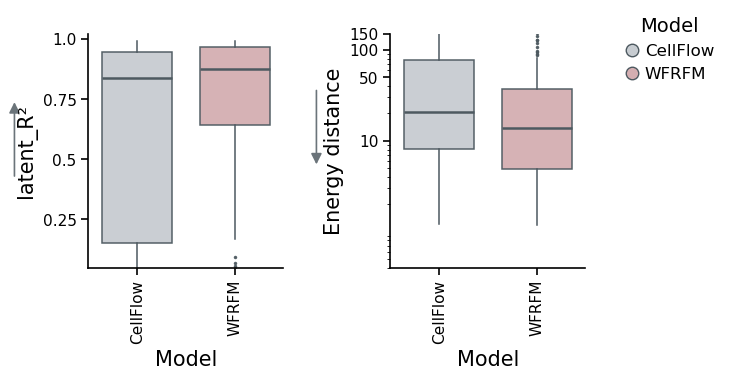

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import numpy as np


# =========================
# 1. 手动配置区
# =========================

# 每个 model 一个 csv
MODEL_FILES = [
    #{"model": "Identity", "path": "results/exp_20260409_140223_Sciplex3_llm_test1_42_cellflow_True_X_pca_100_None_delta6_regm3/identity.csv"},
    {"model": "CellFlow", "path": "results/cellflow_Sciplex3_llm_test1_42_cellflow_True_X_pca_100_None/latent_metrics.csv"},
    {"model": "WFRFM", "path": "results/exp_20260409_140223_Sciplex3_llm_test1_42_cellflow_True_X_pca_100_None_delta6_regm3/latent_metrics.csv"},
]

# 每个子图对应一个指标列
PANELS = [
    {
        "column": "latent_r2",                 # csv 里的列名
  #      "title": "10 μM",               # 子图标题，可手动改
        "ylabel": "latent_R²",                 # y 轴标签，可手动改
        "xlabel": "Model",
        "ylim": (0.05, 1.02),
        "yticks": [0.25, 0.50, 0.75, 1.00],
        "yscale": "linear",

        # 箭头，可手动控制方向
        "arrow": {
            "text": "",
            "direction": "up",          # 可选: "up", "down", "left", "right"
            "x": -0.38,                 # 相对坐标，负值表示放在 y 轴左侧
            "y": 0.55,
            "length": 0.34,
        },

        # 手动文字标注
        "annotations": [
            # {"text": "better", "x": -0.55, "y": 0.88, "fontsize": 12}
        ],
    },
    {
        "column": "latent_energy_distance",    # csv 里的列名
   #     "title": "10 μM",
        "ylabel": "Energy distance",
        "xlabel": "Model",
        "ylim": (0.4, 80),
        "yticks": [10, 50,100,150],
        "yscale": "log",

        "arrow": {
            "text": "",
            "direction": "down",
            "x": -0.38,
            "y": 0.60,
            "length": 0.34,
        },

        "annotations": [
            # {"text": "*", "x": 4.25, "y": 40, "fontsize": 13}
        ],
    },
]

# 颜色会自动循环，model 数量不限
COLORS = [
    "#c7ccd1",  # gray
    "#d4aeb1",  # pink
    "#b9dce8",  # light blue
    "#b89acb",  # purple
    "#b94f89",  # magenta
    "#9ecae1",
    "#f0c987",
    "#a1d99b",
]

FIGSIZE = (7.2, 4.1)
OUTPUT = "model_boxplot.png"


# =========================
# 2. 读入数据
# =========================

def load_metric_data(model_files, column):
    """
    从每个 model 的 csv 中读取指定列，合并成长表。
    """
    dfs = []

    for item in model_files:
        model_name = item["model"]
        path = item["path"]

        df = pd.read_csv(path)

        if column not in df.columns:
            raise ValueError(
                f"Column '{column}' not found in file: {path}\n"
                f"Available columns: {list(df.columns)}"
            )

        tmp = pd.DataFrame({
            "Model": model_name,
            "Value": pd.to_numeric(df[column], errors="coerce")
        })

        tmp = tmp.dropna()
        dfs.append(tmp)

    return pd.concat(dfs, ignore_index=True)


# =========================
# 3. 画图函数
# =========================

def draw_direction_arrow(ax, cfg):
    """
    在子图左侧或指定位置画方向箭头。
    坐标使用 ax.transAxes 的相对坐标。
    """
    if cfg is None:
        return

    direction = cfg.get("direction", "up")
    x = cfg.get("x", -0.35)
    y = cfg.get("y", 0.5)
    length = cfg.get("length", 0.3)
    text = cfg.get("text", "")
    color = cfg.get("color", "#6b747a")

    if direction == "up":
        start = (x, y - length / 2)
        end = (x, y + length / 2)
    elif direction == "down":
        start = (x, y + length / 2)
        end = (x, y - length / 2)
    elif direction == "right":
        start = (x - length / 2, y)
        end = (x + length / 2, y)
    elif direction == "left":
        start = (x + length / 2, y)
        end = (x - length / 2, y)
    else:
        raise ValueError("direction must be one of: up, down, left, right")

    arrow = FancyArrowPatch(
        start,
        end,
        transform=ax.transAxes,
        arrowstyle="-|>",
        mutation_scale=16,
        linewidth=1.2,
        color=color,
        clip_on=False,
    )
    ax.add_patch(arrow)

    if text:
        ax.text(
            x,
            y,
            text,
            transform=ax.transAxes,
            ha="center",
            va="center",
            rotation=90 if direction in ["up", "down"] else 0,
            fontsize=11,
            color=color,
        )


def style_axis(ax):
    """
    设置接近参考图的简洁风格。
    """
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)

    ax.tick_params(axis="both", width=1.2, length=5, labelsize=11)
    ax.grid(False)


def plot_panel(ax, data, panel_cfg, model_order, colors):
    values = [
        data.loc[data["Model"] == model, "Value"].values
        for model in model_order
    ]

    box = ax.boxplot(
        values,
        patch_artist=True,
        widths=0.72,
        showfliers=True,
        medianprops=dict(color="#4d5960", linewidth=1.8),
        boxprops=dict(linewidth=1.1, color="#4d5960"),
        whiskerprops=dict(linewidth=1.1, color="#4d5960"),
        capprops=dict(linewidth=0),  # 参考图中 whisker cap 不明显
        flierprops=dict(
            marker=".",
            markersize=3,
            markerfacecolor="#4d5960",
            markeredgecolor="#4d5960",
            alpha=0.9,
        ),
    )

    for i, patch in enumerate(box["boxes"]):
        patch.set_facecolor(colors[i % len(colors)])
        patch.set_alpha(0.95)

    ax.set_xticks(np.arange(1, len(model_order) + 1))
    ax.set_xticklabels(model_order, rotation=90)

    ax.set_title(panel_cfg.get("title", ""), fontsize=15, pad=10)
    ax.set_ylabel(panel_cfg.get("ylabel", ""), fontsize=15)
    ax.set_xlabel(panel_cfg.get("xlabel", ""), fontsize=15)

    if panel_cfg.get("yscale", "linear") == "log":
        ax.set_yscale("log")

    if panel_cfg.get("ylim") is not None:
        ax.set_ylim(panel_cfg["ylim"])

    if panel_cfg.get("yticks") is not None:
        ax.set_yticks(panel_cfg["yticks"])
        ax.set_yticklabels([str(t) for t in panel_cfg["yticks"]])

    style_axis(ax)

    draw_direction_arrow(ax, panel_cfg.get("arrow"))

    for ann in panel_cfg.get("annotations", []):
        ax.text(
            ann["x"],
            ann["y"],
            ann["text"],
            fontsize=ann.get("fontsize", 12),
            ha=ann.get("ha", "center"),
            va=ann.get("va", "center"),
            color=ann.get("color", "black"),
        )


def plot_multi_model_boxplots(model_files, panels, colors, figsize=(7, 4), output=None):
    model_order = [item["model"] for item in model_files]

    fig, axes = plt.subplots(
        1,
        len(panels),
        figsize=figsize,
        constrained_layout=False,
    )

    if len(panels) == 1:
        axes = [axes]

    for ax, panel_cfg in zip(axes, panels):
        data = load_metric_data(model_files, panel_cfg["column"])
        plot_panel(ax, data, panel_cfg, model_order, colors)

    # 右侧图例
    handles = [
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor=colors[i % len(colors)],
            markeredgecolor="#4d5960",
            markersize=9,
            label=model,
        )
        for i, model in enumerate(model_order)
    ]

    fig.legend(
        handles=handles,
        title="Model",
        loc="upper right",
        bbox_to_anchor=(1.02, 0.92),
        frameon=False,
        fontsize=12,
        title_fontsize=14,
        handlelength=0.8,
        handletextpad=0.4,
    )

    plt.subplots_adjust(
        left=0.13,
        right=0.82,
        bottom=0.27,
        top=0.84,
        wspace=0.55,
    )

    if output is not None:
        plt.savefig(output, dpi=300, bbox_inches="tight")

    plt.show()


# =========================
# 4. 执行绘图
# =========================

plot_multi_model_boxplots(
    model_files=MODEL_FILES,
    panels=PANELS,
    colors=COLORS,
    figsize=FIGSIZE,
    output=OUTPUT,
)


### more downstream

In [49]:
from src.evaluate.util import run_inference_only
results_embedding, _, indices, reducer = run_inference_only(
    model=model,
    adata_control=adata_control,
    adata_test=adata_test,
    wishlist=wishlist,
    condition_keys=condition_keys,
    condition_rep_keys=condition_rep_keys,
    sample_rep=sample_rep,
    device=device,
    n_particles=10000,
    n_steps=50,
    source_celltype_key="cell_line",
    return_traj=True,
    return_reducer=True,
    inference_modes=("all", "v_only", "g_only"),
)


Starting latent inference for 31 conditions...
Running inference for 31 conditions ...
Modes: ['all', 'v_only', 'g_only']


/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Latent inference completed.


In [64]:
ranked = sorted(
    [(k, v["m_pred"].mean()) for k, v in results_embedding.items()],
    key=lambda x: x[1]
)
print(ranked[:10])


[("('Belinostat (PXD101)', 'A549', 10000.0, 72.0)", np.float32(0.026654927)), ("('Dacinostat (LAQ824)', 'A549', 10000.0, 72.0)", np.float32(0.12596546)), ("('Quisinostat (JNJ-26481585) 2HCl', 'A549', 10000.0, 72.0)", np.float32(0.23074012)), ("('Belinostat (PXD101)', 'K562', 10000.0, 24.0)", np.float32(0.3434293)), ("('Dacinostat (LAQ824)', 'K562', 10000.0, 24.0)", np.float32(0.38671246)), ("('Givinostat (ITF2357)', 'K562', 10000.0, 24.0)", np.float32(0.38697803)), ("('Quisinostat (JNJ-26481585) 2HCl', 'K562', 10000.0, 24.0)", np.float32(0.4063067)), ("('Quisinostat (JNJ-26481585) 2HCl', 'A549', 10000.0, 24.0)", np.float32(0.43478337)), ("('Givinostat (ITF2357)', 'A549', 10000.0, 24.0)", np.float32(0.43706945)), ("('Alvespimycin (17-DMAG) HCl', 'MCF7', 10000.0, 24.0)", np.float32(0.45231757))]


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/wfr_multitime_umap_helper.py:504: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


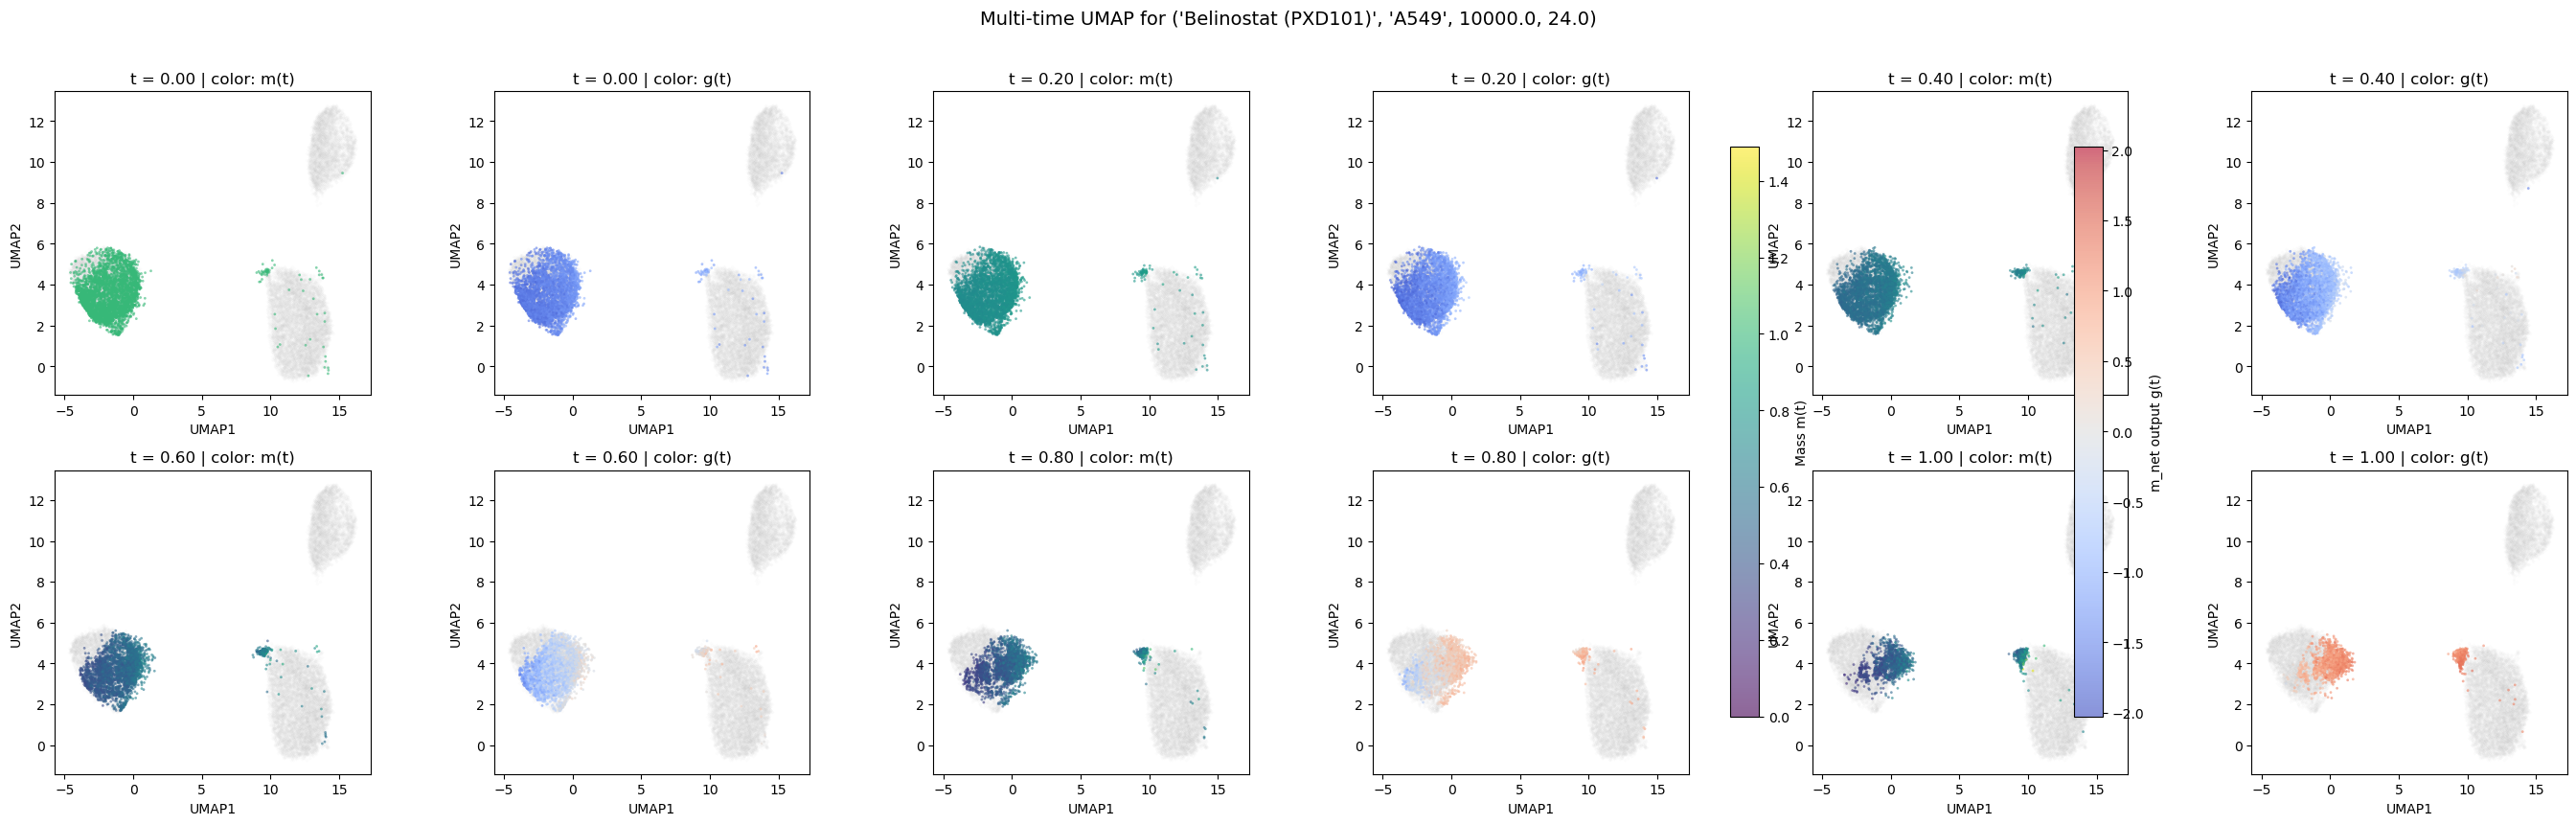

In [35]:
from src.evaluate.wfr_multitime_umap_helper import plot_multitime_umap_for_condition

cond_name = "('Belinostat (PXD101)', 'A549', 10000.0, 24.0)"

fig, axes = plot_multitime_umap_for_condition(
    results=results_embedding,
    cond_name=cond_name,
    adata_source=adata_control[sampled_indices].copy(),
    sample_rep=sample_rep,
    save_times=(0.0, 0.2, 0.4, 0.6, 0.8, 1.0),
    reducer=reducer,
    background="all_source",
    point_alpha=0.6,
    bg_alpha=0.05,
    size_range=(4, 140),   # 这里只会用到 4，表示固定点大小
    cmap="coolwarm",
)


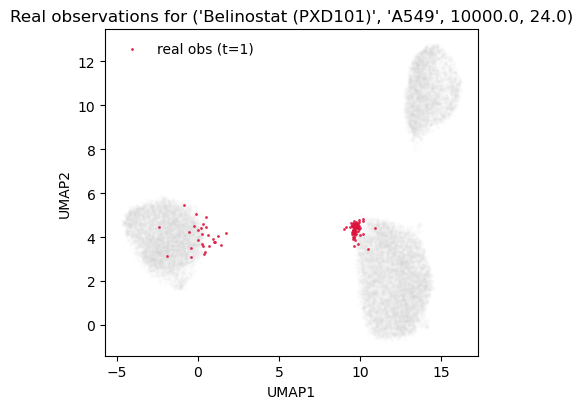

In [36]:
# 取预测图里一个 panel 的坐标范围，保证显示窗口完全一致
xlim = axes[0].get_xlim()
ylim = axes[0].get_ylim()

fig_real, ax_real = plot_real_umap_for_condition(
    adata_test=adata_test,
    cond_name=cond_name,
    condition_key=condition_combined_keys,   # 可以是字符串列名，也可以是列名列表
    reducer=reducer,                         # 关键：一定要用同一个 reducer
    sample_rep=sample_rep,                   # 通常应该在 obsm 里
    adata_background=adata_control[sampled_indices].copy(),
    background="all_source",
    time_key=None,                            # 如果你的时间列叫 t
    time_value=1.0,
    point_color="crimson",
    point_alpha=0.9,
    bg_alpha=0.05,
    point_size=4.0,
    xlim=xlim,
    ylim=ylim,
)


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/wfr_multitime_umap_helper.py:504: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


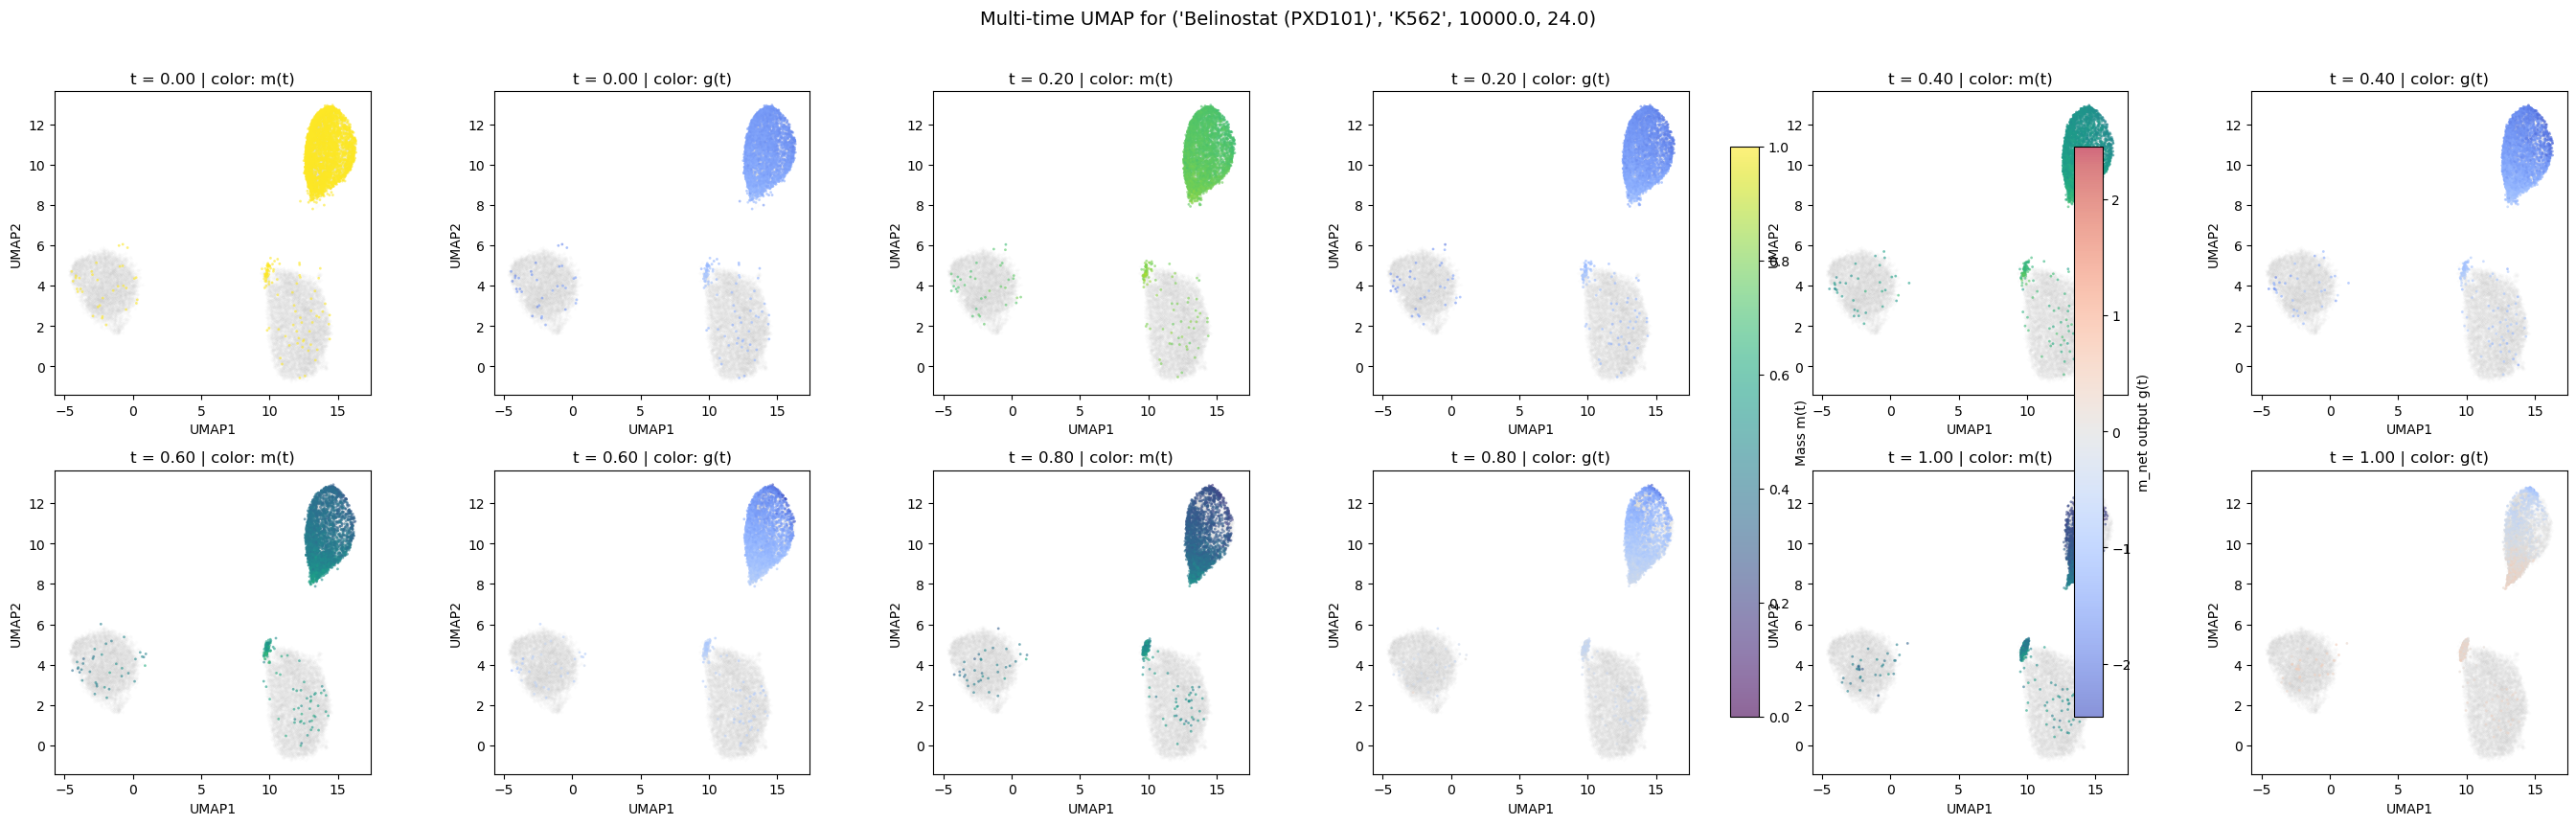

In [37]:
from src.evaluate.wfr_multitime_umap_helper import plot_multitime_umap_for_condition

cond_name = "('Belinostat (PXD101)', 'K562', 10000.0, 24.0)"

fig, axes = plot_multitime_umap_for_condition(
    results=results_embedding,
    cond_name=cond_name,
    adata_source=adata_control[sampled_indices].copy(),
    sample_rep=sample_rep,
    save_times=(0.0, 0.2, 0.4, 0.6, 0.8, 1.0),
    reducer=reducer,
    background="all_source",
    point_alpha=0.6,
    bg_alpha=0.05,
    size_range=(4, 140),   # 这里只会用到 4，表示固定点大小
    cmap="coolwarm",
)

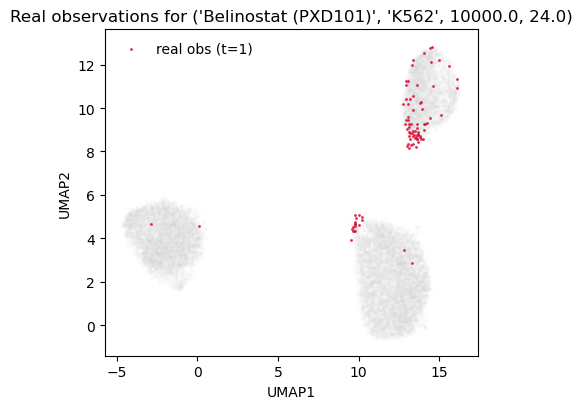

In [38]:
# 取预测图里一个 panel 的坐标范围，保证显示窗口完全一致
xlim = axes[0].get_xlim()
ylim = axes[0].get_ylim()

fig_real, ax_real = plot_real_umap_for_condition(
    adata_test=adata_test,
    cond_name=cond_name,
    condition_key=condition_combined_keys,   # 可以是字符串列名，也可以是列名列表
    reducer=reducer,                         # 关键：一定要用同一个 reducer
    sample_rep=sample_rep,                   # 通常应该在 obsm 里
    adata_background=adata_control[sampled_indices].copy(),
    background="all_source",
    time_key=None,                            # 如果你的时间列叫 t
    time_value=1.0,
    point_color="crimson",
    point_alpha=0.9,
    bg_alpha=0.05,
    point_size=4.0,
    xlim=xlim,
    ylim=ylim,
)


/lustre/home/2300012136/mycode/DynamicVirtualCell/WFRFM/src/evaluate/wfr_multitime_umap_helper.py:504: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


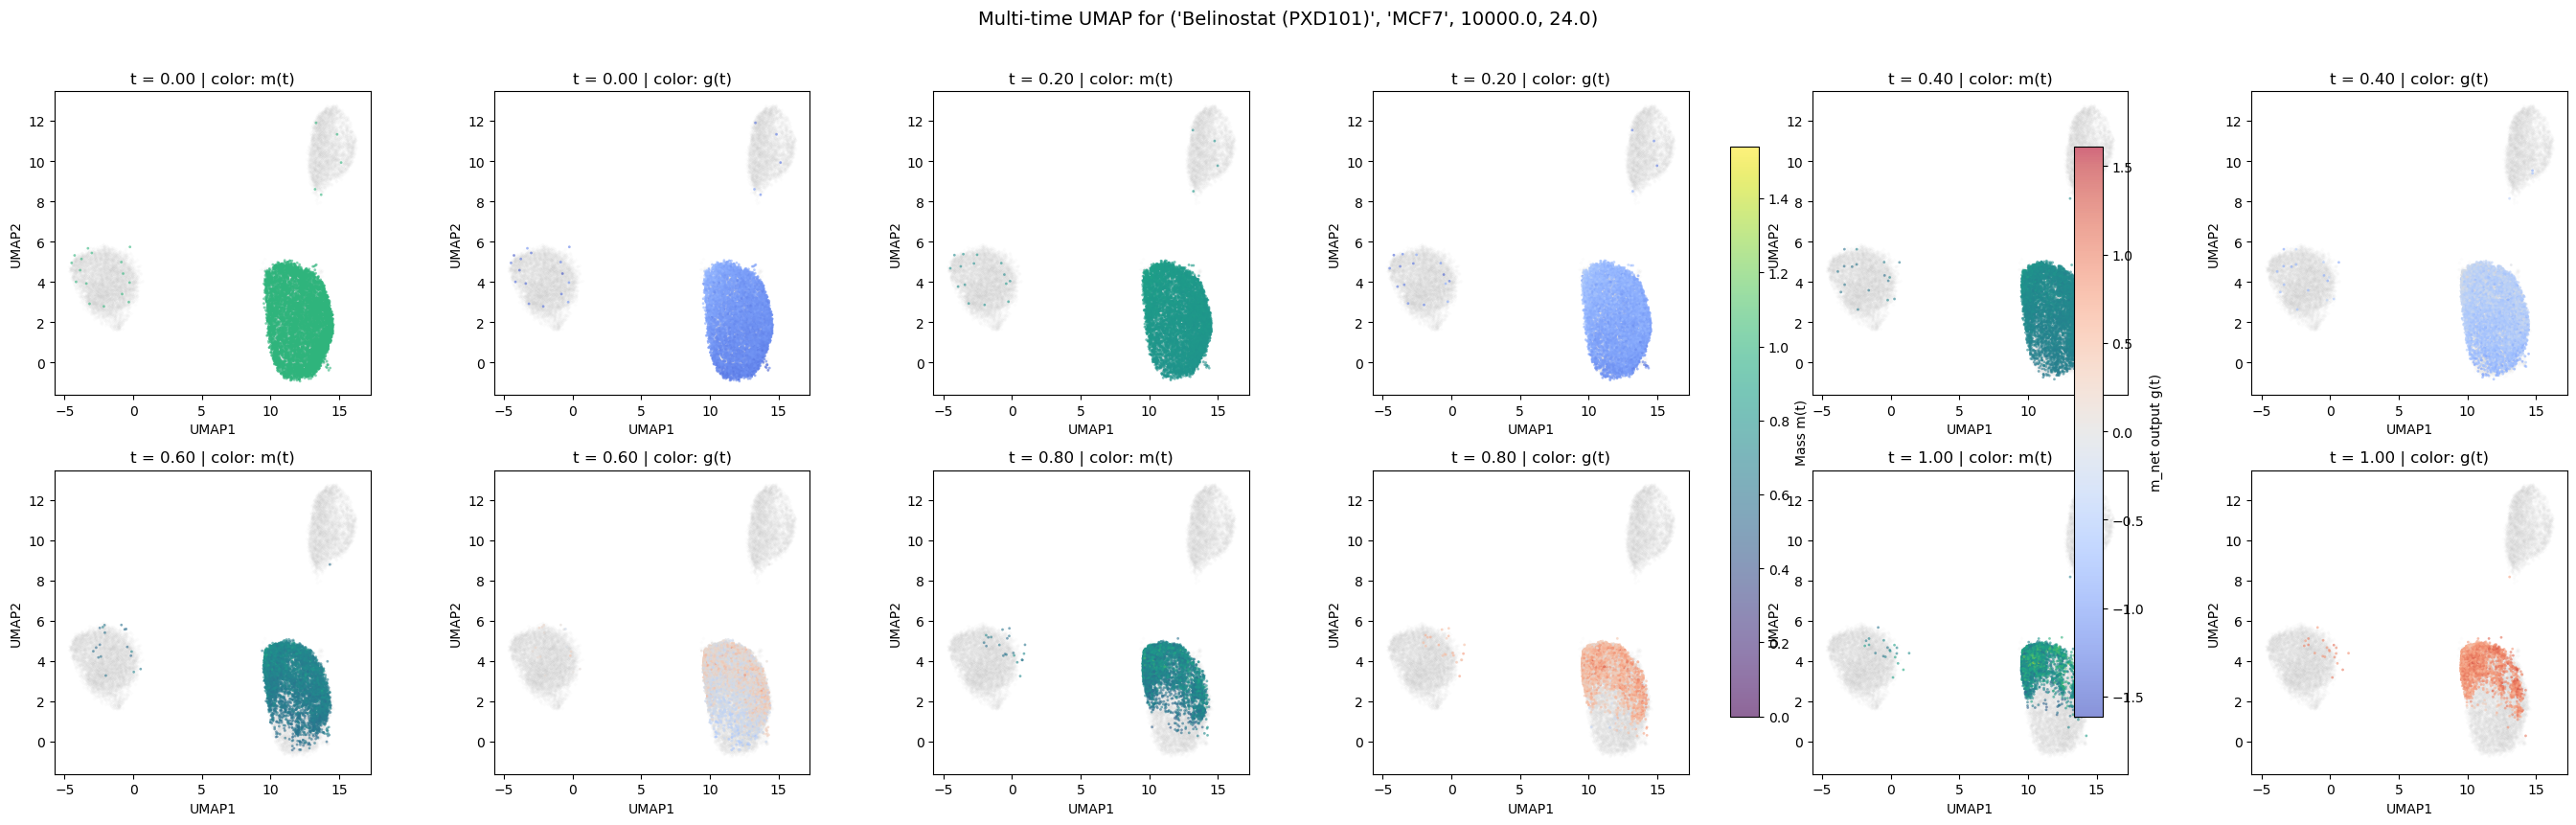

In [39]:
cond_name = "('Belinostat (PXD101)', 'MCF7', 10000.0, 24.0)"

fig, axes = plot_multitime_umap_for_condition(
    results=results_embedding,
    cond_name=cond_name,
    adata_source=adata_control[sampled_indices].copy(),
    sample_rep=sample_rep,
    save_times=(0.0, 0.2, 0.4, 0.6, 0.8, 1.0),
    reducer=reducer,
    background="all_source",
    point_alpha=0.6,
    bg_alpha=0.05,
    size_range=(4, 140),   # 这里只会用到 4，表示固定点大小
    cmap="coolwarm",
)

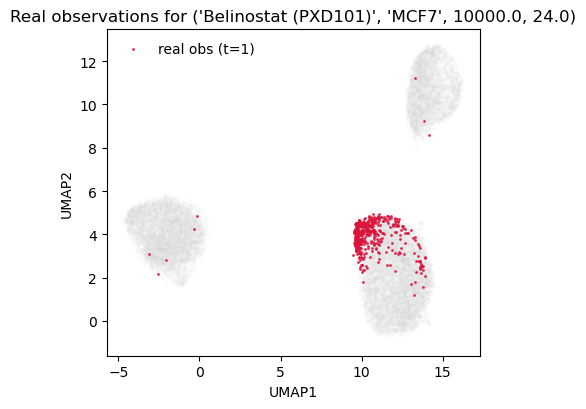

In [40]:
# 取预测图里一个 panel 的坐标范围，保证显示窗口完全一致
xlim = axes[0].get_xlim()
ylim = axes[0].get_ylim()

fig_real, ax_real = plot_real_umap_for_condition(
    adata_test=adata_test,
    cond_name=cond_name,
    condition_key=condition_combined_keys,   # 可以是字符串列名，也可以是列名列表
    reducer=reducer,                         # 关键：一定要用同一个 reducer
    sample_rep=sample_rep,                   # 通常应该在 obsm 里
    adata_background=adata_control[sampled_indices].copy(),
    background="all_source",
    time_key=None,                            # 如果你的时间列叫 t
    time_value=1.0,
    point_color="crimson",
    point_alpha=0.9,
    bg_alpha=0.05,
    point_size=4.0,
    xlim=xlim,
    ylim=ylim,
)


In [ ]:
with open(f"{results_save_path}_test", "wb") as f:
    artifacts = pickle.load(f)

In [ ]:
indices = artifacts["indices"]
results_embedding = artifacts["results_embedding"]
results_genes = artifacts["results_genes"]
adata_source = adata_control[indices]

In [ ]:
print(adata_test.obs["cell_type"].value_counts().to_string())

In [49]:
cell_line = "A549"

In [50]:
adata_control_cellline = adata_control[adata_control.obs["cell_line"]==cell_line].copy()

In [51]:
sc.tl.pca(adata_control, svd_solver='arpack')
sc.pp.neighbors(adata_control, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata_control)

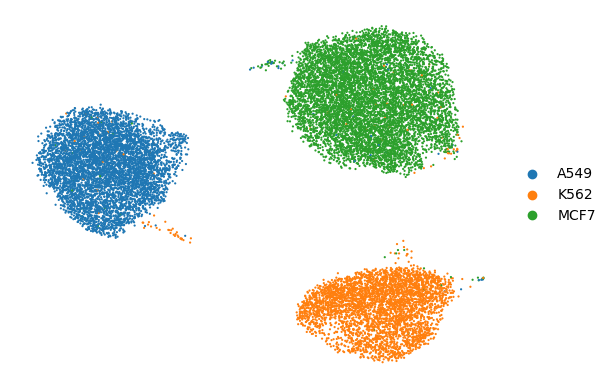

In [52]:
sc.pl.umap(
    adata_control, 
    color='cell_line',      # 按细胞类型着色
    frameon=False,          # 【关键】去掉周围的黑框和坐标轴
    title='',               # 去掉标题（方便后期AI排版）
    legend_fontsize=10,     # 标签字体大小
    size=10,                # 调整点的大小
    save='celltype.pdf'    # 保存为矢量图
)
# sc.pl.umap(
#     adata_control, 
#     vmin=0,
#     vmax=6,
#     color=[f'FCN1', f'IDO1'], 
# )

In [32]:
adata_test.obs["perturbation"].value_counts()

perturbation
Belinostat (PXD101)                4808
Dacinostat (LAQ824)                3609
Givinostat (ITF2357)               3545
Hesperadin                         3316
Quisinostat (JNJ-26481585) 2HCl    3025
TAK-901                            2559
Tanespimycin (17-AAG)              2488
Alvespimycin (17-DMAG) HCl         2089
Flavopiridol HCl                   1729
Name: count, dtype: int64

In [47]:
adata_true = adata_test[adata_test.obs["perturbation"]=="Flavopiridol HCl"].copy()
adata_true = adata_true[adata_true.obs["cell_line"]==cell_line].copy()
adata_pred = results_genes[f"('Flavopiridol HCl', {cell_line}, 10000.0, 24.0)"]

In [48]:
sc.tl.ingest(adata_true, adata_control, embedding_method='umap')
sc.tl.ingest(adata_pred, adata_control, embedding_method='umap')

/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/lustre/home/2300012136/software/miniconda3/envs/dvc-cellflow/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [38]:
adata_control.obs['dataset'] = 'Control'
adata_true.obs['dataset'] = 'True'
adata_pred.obs['dataset'] = 'Pred'

/tmp/ipykernel_2744407/2058570734.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_all = adata_control.concatenate(adata_true, batch_key='dataset',batch_categories=["Control", "True"])


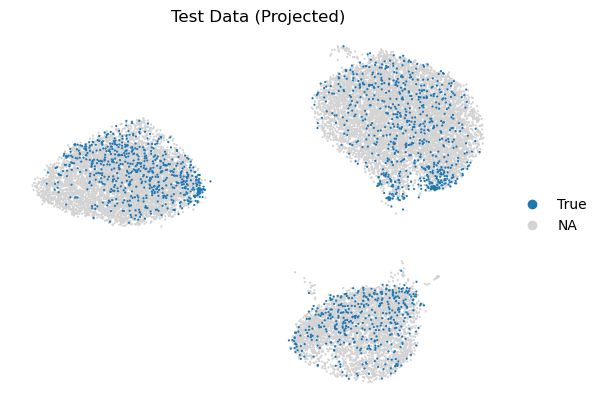

In [39]:
adata_all = adata_control.concatenate(adata_true, batch_key='dataset',batch_categories=["Control", "True"])

adata_all.obs['plot_color'] = adata_all.obs['dataset'].astype(str)
color_map = {'Control': 'black', 'True': '#1f77b4'} # 也可以用 hex 颜色码

# sc.pl.umap(
#     adata_all, 
#     color='plot_color', 
#     groups=['Control'], # 只高亮 Control
#     palette=color_map,
#     frameon=False,
#     title='Control',
#     size=10 # 根据细胞数调整点大小
# )

sc.pl.umap(
    adata_all, 
    color='plot_color', 
    groups=['True'],    # 只高亮 Test
    palette=color_map,
    frameon=False,
    title='Test Data (Projected)',
    size=10
)
# import numpy as np

# # 1. 复制一个用于绘图的对象，以免修改原数据
# adata_plot = adata_all.copy()

# # 2. 将 'Control' 组的这两个基因的表达量设为 NaN (空值)
# # 这样 Scanpy 就会把它们识别为缺失值，并涂上 na_color
# mask_control = adata_plot.obs['dataset'] == 'Control'

# # 注意：如果 .X 是稀疏矩阵，操作稍微麻烦点；如果是 dense 矩阵或已放到 .obs 里可以直接操作
# # 这里演示最通用的方法：先把基因值存入 obs，再手动修改
# for gene in ['FCN1', 'IDO1']:
#     # 获取表达量 (处理稀疏矩阵的情况)
#     if hasattr(adata_plot.X, "toarray"):
#         values = adata_plot[:, gene].X.toarray().flatten()
#     else:
#         values = adata_plot[:, gene].X.flatten()
    
#     # 存入 obs
#     adata_plot.obs[f'plot_{gene}'] = values
    
#     # 将 Control 组的值设为 NaN
#     adata_plot.obs.loc[mask_control, f'plot_{gene}'] = np.nan

# # 3. 绘图
# sc.pl.umap(
#     adata_plot, 
#     color=[f'plot_FCN1', f'plot_IDO1'], 
#     na_color='lightgrey', # 这里设置背景色（Control的颜色）
#     na_in_legend=False,   # 图例中不显示 NaN
#     cmap='viridis',       # Pred 组的颜色映射
#     frameon=False,
#     vmin=0,
#     vmax=6,
#     size=10,
#     title=['FCN1 (True Only)', 'IDO1 (True Only)']
# )


/tmp/ipykernel_2744407/1497717609.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_all = adata_control.concatenate(adata_pred, batch_key='dataset',batch_categories=["Control", "Pred"])


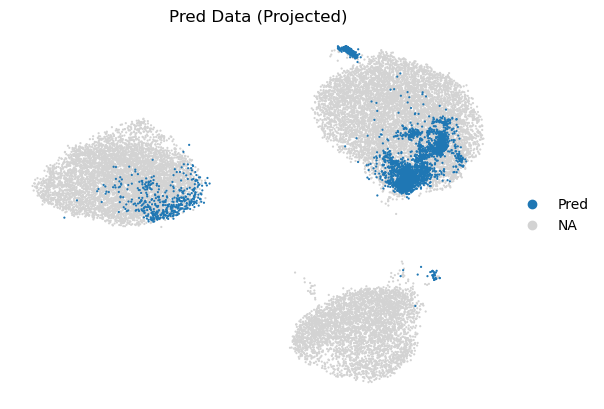

In [40]:
adata_all = adata_control.concatenate(adata_pred, batch_key='dataset',batch_categories=["Control", "Pred"])

adata_all.obs['plot_color'] = adata_all.obs['dataset'].astype(str)
color_map = {'Control': 'black', 'Pred': '#1f77b4'} # 也可以用 hex 颜色码

sc.pl.umap(
    adata_all, 
    color='plot_color', 
    groups=['Pred'],    # 只高亮 Test
    palette=color_map,
    frameon=False,
    title='Pred Data (Projected)',
    size=10
)


# import numpy as np

# # 1. 复制一个用于绘图的对象，以免修改原数据
# adata_plot = adata_all.copy()

# # 2. 将 'Control' 组的这两个基因的表达量设为 NaN (空值)
# # 这样 Scanpy 就会把它们识别为缺失值，并涂上 na_color
# mask_control = adata_plot.obs['dataset'] == 'Control'

# # 注意：如果 .X 是稀疏矩阵，操作稍微麻烦点；如果是 dense 矩阵或已放到 .obs 里可以直接操作
# # 这里演示最通用的方法：先把基因值存入 obs，再手动修改
# for gene in ['FCN1', 'IDO1']:
#     # 获取表达量 (处理稀疏矩阵的情况)
#     if hasattr(adata_plot.X, "toarray"):
#         values = adata_plot[:, gene].X.toarray().flatten()
#     else:
#         values = adata_plot[:, gene].X.flatten()
    
#     # 存入 obs
#     adata_plot.obs[f'plot_{gene}'] = values
    
#     # 将 Control 组的值设为 NaN
#     adata_plot.obs.loc[mask_control, f'plot_{gene}'] = np.nan

# # 3. 绘图
# sc.pl.umap(
#     adata_plot, 
#     color=[f'plot_FCN1', f'plot_IDO1'], 
#     na_color='lightgrey', # 这里设置背景色（Control的颜色）
#     na_in_legend=False,   # 图例中不显示 NaN
#     cmap='viridis',       # Pred 组的颜色映射
#     frameon=False,
#     vmin=0,
#     vmax=6,
#     size=10,
#     title=['FCN1 (Pred Only)', 'IDO1 (Pred Only)']
# )
# import numpy as np

# # 1. 复制一份用于绘图，避免污染原数据
# adata_plot = adata_all.copy()

# # 2. 初始化一个新的列用于绘图，先全部设为 NaN (灰色)
# adata_plot.obs['plot_mass'] = np.nan

# # 3. 找到 Pred 组的位置
# mask_pred = adata_plot.obs['dataset'] == 'Pred'

# # 4. 将 mass 的值填入 Pred 组对应的位置
# # .values 确保赋值时忽略索引名称差异（concat 可能会改索引名）
# adata_plot.obs.loc[mask_pred, 'plot_mass'] = adata_pred.obs['mass'].values

# # 5. 绘图
# sc.pl.umap(
#     adata_plot, 
#     color='plot_mass', 
#     na_color='lightgrey', # Control 组（NaN）显示的颜色
#     na_in_legend=False,   # 图例中不显示灰色
#     cmap='viridis',       # mass 的色阶
#     frameon=False,
#     size=10,
#     title='Mass on Projected Data'
# )

In [ ]:
adata_pred

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def diagnose_mass_prediction(pred_adata, gene_name='CDCA2'):
    mass = pred_adata.obs['mass'].values
    expr = pred_adata[:, gene_name].X.flatten() # 或者是 .layers['counts'] 等
    
    # 1. 打印统计数据
    print(f"=== Mass Statistics for {gene_name} prediction ===")
    print(f"Mean Mass: {np.mean(mass):.4f}")
    print(f"Max  Mass: {np.max(mass):.4f}")
    print(f"Min  Mass: {np.min(mass):.4f}")
    print(f"Std  Mass: {np.std(mass):.4f}")
    
    # 2. 绘图：Mass vs Target Gene Expression
    plt.figure(figsize=(10, 4))
    
    # 子图1: Mass 的直方图
    plt.subplot(1, 2, 1)
    plt.hist(mass, bins=50, color='green', alpha=0.7)
    plt.title("Distribution of Predicted Mass")
    plt.xlabel("Mass")
    plt.ylabel("Count")
    
    # 子图2: Mass vs Expression
    plt.subplot(1, 2, 2)
    plt.scatter(expr, mass, alpha=0.5, s=10, c=mass, cmap='viridis')
    plt.title(f"Mass vs {gene_name} Expression")
    plt.xlabel(f"{gene_name} Expression")
    plt.ylabel("Predicted Mass")
    plt.colorbar(label='Mass')
    
    plt.tight_layout()
    plt.show()

# 运行诊断
for gene in target_genes:
    diagnose_mass_prediction(results_genes[gene], gene)